In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay

from xgboost import XGBClassifier, plot_importance



In [36]:

X_train = np.load("../data/processed/rul_dataset/X_train.npy")
X_test = np.load("../data/processed/rul_dataset/X_test.npy")

y_failure_train = np.load("../data/processed/rul_dataset/y_failure_train.npy")
y_failure_test = np.load("../data/processed/rul_dataset/y_failure_test.npy")

In [37]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_failure_train:", y_failure_train.shape)
print("y_failure_test:", y_failure_test.shape)

print("Failure classes:", np.unique(y_failure_train, return_counts=True))

X_train: (14241, 30, 15)
X_test: (3490, 30, 15)
y_failure_train: (14241,)
y_failure_test: (3490,)
Failure classes: (array([0, 1]), array([11761,  2480]))


In [38]:
X_train_fp = X_train[:, -1, :]
X_test_fp = X_test[:, -1, :]

print("X_train_fp:", X_train_fp.shape)
print("X_test_fp:", X_test_fp.shape)

X_train_fp: (14241, 15)
X_test_fp: (3490, 15)


In [39]:
X_train_fp, X_val_fp, y_train_fp, y_val_fp = train_test_split(X_train_fp, y_failure_train, test_size=0.2, random_state=42, stratify=y_failure_train)

print("Train:", X_train_fp.shape)
print("Validation:", X_val_fp.shape)
print("Test:", X_test_fp.shape)

Train: (11392, 15)
Validation: (2849, 15)
Test: (3490, 15)


In [40]:
print("Training classes:")
print(np.unique(y_train_fp, return_counts=True))

print("\nValidation classes:")
print(np.unique(y_val_fp, return_counts=True))

print("\nTest classes:")
print(np.unique(y_failure_test, return_counts=True))

Training classes:
(array([0, 1]), array([9408, 1984]))

Validation classes:
(array([0, 1]), array([2353,  496]))

Test classes:
(array([0, 1]), array([2870,  620]))


In [41]:
negative, positive = np.bincount(y_train_fp)

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("scale_pos_weight:", scale_pos_weight)

Negative: 9408
Positive: 1984
scale_pos_weight: 4.741935483870968


In [42]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)


In [43]:
model.fit(
    X_train_fp,
    y_train_fp,
    eval_set=[(X_val_fp, y_val_fp)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [44]:
y_test_prob = model.predict_proba(X_test_fp)[:, 1]

y_test_pred = (y_test_prob >= 0.5).astype(int)

In [45]:
print("Classification Report:")
print(classification_report(y_failure_test, y_test_pred, target_names=["Normal", "Failure"]))

print("ROC-AUC:", roc_auc_score(y_failure_test, y_test_prob))

print("PR-AUC:", average_precision_score(y_failure_test, y_test_prob ))

print("\nConfusion Matrix:")
print(confusion_matrix(y_failure_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.96      2870
     Failure       0.77      0.94      0.85       620

    accuracy                           0.94      3490
   macro avg       0.88      0.94      0.91      3490
weighted avg       0.95      0.94      0.94      3490

ROC-AUC: 0.988119590873328
PR-AUC: 0.9564231843653807

Confusion Matrix:
[[2701  169]
 [  39  581]]


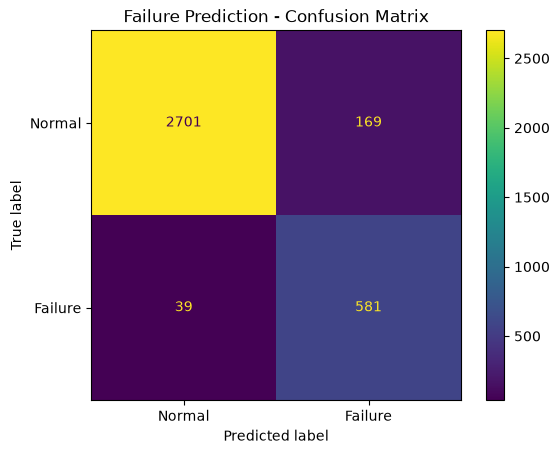

In [46]:
ConfusionMatrixDisplay.from_predictions(y_failure_test, y_test_pred, display_labels=["Normal", "Failure"])

plt.title("Failure Prediction - Confusion Matrix")
plt.show()

<Figure size 1000x600 with 0 Axes>

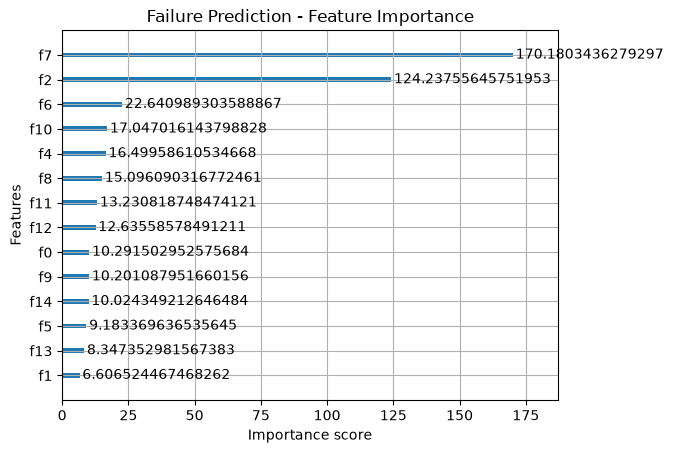

In [47]:
plt.figure(figsize=(10, 6))

plot_importance(model, importance_type="gain", max_num_features=15)

plt.title("Failure Prediction - Feature Importance")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "../models/failure_prediction_xgboost.pkl")

['../models/failure_prediction_xgboost.pkl']

Logistic Regression baseline

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(
    X_train_fp,
    y_train_fp
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [ ]:
y_baseline_prob = baseline_model.predict_proba(X_test_fp)[:, 1]

y_baseline_pred = (y_baseline_prob >= 0.5).astype(int)

In [ ]:
print("Logistic Regression Classification Report:")
print(classification_report(y_failure_test, y_baseline_pred, target_names=["Normal", "Failure"]))

print("ROC-AUC:", roc_auc_score(y_failure_test, y_baseline_prob))

print("PR-AUC:", average_precision_score(y_failure_test, y_baseline_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_failure_test, y_baseline_pred))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.92      0.96      2870
     Failure       0.73      0.97      0.83       620

    accuracy                           0.93      3490
   macro avg       0.86      0.95      0.90      3490
weighted avg       0.95      0.93      0.94      3490

ROC-AUC: 0.9906305496234686
PR-AUC: 0.9632801738006865

Confusion Matrix:
[[2651  219]
 [  20  600]]


Logistic Regression wins:

ROC-AUC, 
PR-AUC, 
Failure recall, 
False negatives, 

XGBoost wins:

Accuracy, 
Failure precision, 
Failure F1, 
False positives, 